In [1]:
!pip install nltk pandas matplotlib

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [3]:
def analyze_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']

    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return sentiment, compound

In [4]:
text = input("Enter a sentence: ")

sentiment, score = analyze_sentiment(text)

print("\nText:", text)
print("Sentiment:", sentiment)
print("Sentiment Score:", score)

Enter a sentence: I really love this application!

Text: I really love this application!
Sentiment: Positive
Sentiment Score: 0.6989


In [5]:
texts = [
    "I love this product!",
    "The service was excellent.",
    "This is an amazing experience.",
    "I don't like this product.",
    "The service was terrible.",
    "I am very disappointed.",
    "The product is okay."
]

results = []

for text in texts:
    sentiment, score = analyze_sentiment(text)

    results.append({
        "Text": text,
        "Sentiment": sentiment,
        "Score": score
    })

df = pd.DataFrame(results)

df

,Text,Sentiment,Score
0,I love this product!,Positive,0.6696
1,The service was excellent.,Positive,0.5719
2,This is an amazing experience.,Positive,0.5859
3,I don't like this product.,Negative,-0.2755
4,The service was terrible.,Negative,-0.4767
5,I am very disappointed.,Negative,-0.5256
6,The product is okay.,Positive,0.2263


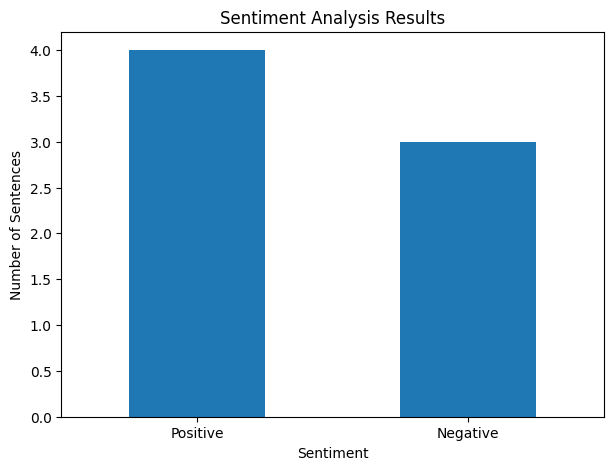

In [6]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Analysis Results")
plt.xlabel("Sentiment")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)

plt.show()

In [7]:
print("========================================")
print("       SENTIMENT ANALYSIS SYSTEM")
print("========================================")

while True:
    text = input("\nEnter text (type 'exit' to stop): ")

    if text.lower() == "exit":
        print("Thank you for using Sentiment Analysis System!")
        break

    sentiment, score = analyze_sentiment(text)

    print("\nAnalysis Result")
    print("----------------------------")
    print("Text      :", text)
    print("Sentiment :", sentiment)
    print("Score     :", round(score, 4))

    if sentiment == "Positive":
        print("Overall feeling: Positive 😊")
    elif sentiment == "Negative":
        print("Overall feeling: Negative 😞")
    else:
        print("Overall feeling: Neutral 😐")

       SENTIMENT ANALYSIS SYSTEM

Enter text (type 'exit' to stop): hiii 

Analysis Result
----------------------------
Text      : hiii 
Sentiment : Neutral
Score     : 0.0
Overall feeling: Neutral 😐

Enter text (type 'exit' to stop): exit
Thank you for using Sentiment Analysis System!
